In [63]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('raw_data.csv', encoding='latin-1')
index = pd.read_csv('game_index.csv', encoding='latin-1')

print(raw.shape)
print(raw.head())
print(raw.columns.tolist())
print(index.columns.tolist())


(152, 20)
  game_id observation_date observation_time  days_to_kickoff kickoff_date  \
0     G01        6/21/2026          2:00 PM              4.0    6/25/2026   
1     G02        6/21/2026          2:00 PM              4.0    6/25/2026   
2     G03        6/21/2026          2:00 PM              4.0    6/25/2026   
3     G04        6/21/2026          2:00 PM              5.0    6/26/2026   
4     G05        6/21/2026          2:00 PM              5.0    6/26/2026   

       team_1 team_1_actual        team_2 team_2_actual        round  \
0         USA           USA        Turkey        Turkey  Group Stage   
1       Japan         Japan        Sweden        Sweden  Group Stage   
2     Curacao       Curacao   Ivory Coast   Ivory Coast  Group Stage   
3      France        France        Norway        Norway  Group Stage   
4  Cape Verde    Cape Verde  Saudi Arabia  Saudi Arabia  Group Stage   

                  venue          city  capacity host_nation  t1_fifa_rank  \
0   Los Angeles S

In [62]:
raw['observation_date'] = pd.to_datetime(raw['observation_date'])

completed_games = ['G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10']
raw_completed = raw[raw['game_id'].isin(completed_games)]

print(raw_completed['game_id'].value_counts())

# Combine date and time into single datetime column
raw_completed = raw_completed.copy()
raw_completed['obs_datetime'] = pd.to_datetime(
    raw_completed['observation_date'].astype(str) + ' ' + 
    raw_completed['observation_time'].astype(str)
)

game_id
G09    17
G10    17
G08    16
G07    15
G05    10
G06    10
G04     9
G01     8
G02     8
G03     8
Name: count, dtype: int64


/var/folders/2s/c_ncbyzd06s15k89762gfc780000gn/T/ipykernel_930/3566212309.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_completed['obs_datetime'] = pd.to_datetime(


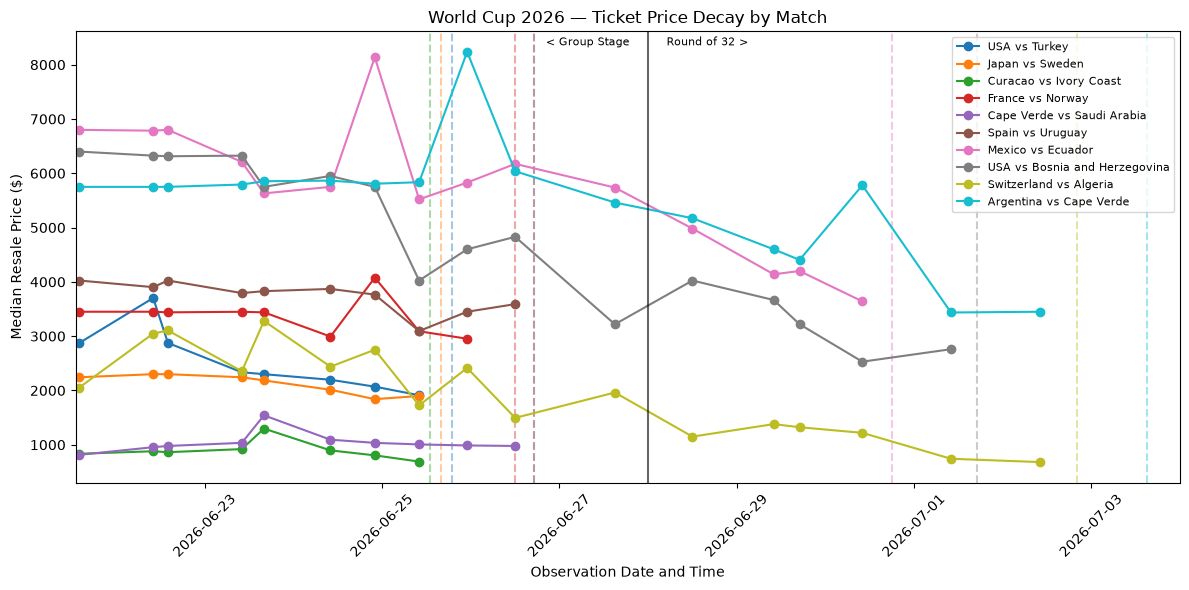

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))

kickoff_times = {
    'G01': '2026-06-25 19:00',  # USA vs Turkey
    'G02': '2026-06-25 16:00',  # Japan vs Sweden
    'G03': '2026-06-25 13:00',  # Curacao vs Ivory Coast
    'G04': '2026-06-26 12:00',  # France vs Norway
    'G05': '2026-06-26 17:00',  # Cape Verde vs Saudi Arabia
    'G06': '2026-06-26 17:00',  # Spain vs Uruguay
    'G07': '2026-06-30 18:00',  # Mexico vs Ecuador
    'G08': '2026-07-01 17:00',  # USA vs Bosnia and Herzegovina
    'G09': '2026-07-02 20:00',  # Switzerland vs Algeria
    'G10': '2026-07-03 15:00',  # Argentina vs Cape Verde
}

for game_id, group in raw_completed.groupby('game_id'):
    label = f"{group['team_1_actual'].iloc[0]} vs {group['team_2_actual'].iloc[0]}"
    group = group.sort_values('obs_datetime', ascending=True)
    line, = ax.plot(group['obs_datetime'], group['median_price'], marker='o', label=label)

    if game_id in kickoff_times:
        kickoff = pd.to_datetime(kickoff_times[game_id])
        ax.axvline(x=kickoff, color=line.get_color(), linestyle='--', alpha=0.4)

ax.set_xlim(
    pd.to_datetime('2026-06-21 13:00'),
    pd.to_datetime('2026-07-04')
)

ax.axvline(
    x=pd.to_datetime('2026-06-28'),
    color='black',
    linestyle='-',
    linewidth=1.5,
    alpha=0.6
)
ax.text(
    pd.to_datetime('2026-06-27 19:00'),
    ax.get_ylim()[1] * 0.97,
    '< Group Stage',
    fontsize=8,
    ha='right',
    color='black'
)
ax.text(
    pd.to_datetime('2026-06-28 5:00'),
    ax.get_ylim()[1] * 0.97,
    'Round of 32 >',
    fontsize=8,
    ha='left',
    color='black'
)

ax.set_xlabel('Observation Date and Time')
ax.set_ylabel('Median Resale Price ($)')
ax.set_title('World Cup 2026 — Ticket Price Decay by Match')
ax.legend(loc='upper right', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()